# Verification: Heterogeneous Bivalent Hapten-Receptor Cross-Linking
# (Goldstein & Wofsy, 1980, Fig. 5)

Compares NFsim equilibrium output against the analytic equilibrium
theory of Goldstein and Wofsy (1980), Eqs. 13–14.

**Claim validated:** Figure 5, $X_T = 500$ IgE molecules/cell curve —
the fraction of antibody cross-linked ($x_{\text{poly}}$) vs bivalent
ligand concentration, with $r_1 = r_2 = 0.5$,
$K_1 = 5 \times 10^6\ \text{M}^{-1}$,
$K_2 = 5 \times 10^8\ \text{M}^{-1}$.

**Reference:** Goldstein B, Wofsy C (1980). *J Math Biol* 10:347–366.

In [1]:
import subprocess, os, glob, re
import numpy as np
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.')

# --- Paper parameters (Goldstein & Wofsy, 1980, Fig. 5 caption) ---
NA = 6.02214076e23
S_cell = 4.7e-6        # cm^2/cell
r1, r2 = 0.5, 0.5
K1 = 5e6               # M^-1
K2 = 5e8               # M^-1
kappa = 4e-15          # cm^2 M / molecule
XT = 500               # IgE molecules/cell

# NFsim scaling (matches BNGL file)
f_val = 0.1
V_sim = 1e-9 * f_val   # L
RT = XT * f_val         # = 50 molecules

# Half-decade spacing: 1e-12, 3e-12, 1e-11, ... 3e-5, 1e-4
A_scan = np.array([v * 10.**e for e in range(-12, -3)
                   for v in (1, 3)][:17] + [1e-4])
A_fine = np.logspace(-12, -4, 500)  # smooth theory curve
n_reps = 10

print(f'RT = {RT:.0f} molecules, {n_reps} reps/point')
print(f'{len(A_scan)} scan points from {A_scan[0]:.0e} to {A_scan[-1]:.0e} M')
print(f'Total NFsim runs: {len(A_scan) * n_reps}')

RT = 50 molecules, 10 reps/point
18 scan points from 1e-12 to 1e-04 M
Total NFsim runs: 180


## Equilibrium theory (Goldstein & Wofsy, 1980)

$$\delta_{ij} = \frac{4\,\kappa\,X_T\,K_i\,K_j\,A}
{(1 + 2 K_i A)(1 + 2 K_j A)}, \qquad
r_i = w_i \left[1 + \frac{\sum_j \delta_{ij} w_j}
{1 - \sum_j \delta_{jj} w_j}\right]^2$$

$x_{\text{poly}} = 1 - w_1 - w_2$ (Eq. 14).

Rearranging the conservation law yields a **quadratic in $w_2$**
given $w_1$ (and vice versa):

$$r_2\,\delta_{22}^2\,w_2^2
- \bigl(2\,r_2\,(1-\beta)\,\delta_{22} + \alpha\bigr)\,w_2
+ r_2\,(1-\beta)^2 = 0,$$

where $\alpha = (1+(\delta_{12}-\delta_{11})w_1)^2$ and
$\beta = \delta_{11}\,w_1$. The **smaller root** satisfies
$\sum \delta_{jj} w_j < 1$.  Alternating between the two
quadratics converges robustly even when $\delta_{22} \gg 1$.

In [2]:
def _solve_w2_given_w1(w1, d11, d12, d22, r2):
    """Solve the quadratic for w2 given w1 (smaller root)."""
    alpha = (1.0 + (d12 - d11) * w1)**2
    beta = d11 * w1
    ob = 1.0 - beta  # 1 - beta
    aa = r2 * d22**2
    bb = 2.0 * r2 * ob * d22 + alpha
    cc = r2 * ob**2
    if aa < 1e-30:
        return min(cc / max(bb, 1e-30), r2)
    disc = bb * bb - 4.0 * aa * cc
    if disc < 0:
        disc = 0.0
    # Numerically stable smaller root: 2c / (b + sqrt(disc))
    return min(2.0 * cc / (bb + np.sqrt(disc)), r2)


def _solve_w1_given_w2(w2, d11, d12, d22, r1):
    """Solve the quadratic for w1 given w2 (smaller root)."""
    gamma = (1.0 + (d12 - d22) * w2)**2
    eps = d22 * w2
    oe = 1.0 - eps  # 1 - eps
    aa = r1 * d11**2
    bb = 2.0 * r1 * oe * d11 + gamma
    cc = r1 * oe**2
    if aa < 1e-30:
        return min(cc / max(bb, 1e-30), r1)
    disc = bb * bb - 4.0 * aa * cc
    if disc < 0:
        disc = 0.0
    return min(2.0 * cc / (bb + np.sqrt(disc)), r1)


def goldstein_xpoly(A_vals, XT_per_cell, K1, K2, kappa, S_cell, r1, r2):
    """Solve Goldstein & Wofsy (1980) Eq. 13 via alternating quadratics."""
    XT_d = XT_per_cell / S_cell
    xpoly = np.zeros(len(A_vals))
    w1, w2 = r1, r2

    for i, A in enumerate(A_vals):
        d1 = 1.0 + 2.0 * K1 * A
        d2 = 1.0 + 2.0 * K2 * A
        c = 4.0 * kappa * XT_d * A
        d11 = c * K1**2 / (d1 * d1)
        d12 = c * K1 * K2 / (d1 * d2)
        d22 = c * K2**2 / (d2 * d2)

        # Clamp initial guess so S < 1
        if d22 > 0 and d22 * w2 > 0.45:
            w2 = 0.45 / d22
        if d11 * w1 + d22 * w2 >= 0.95:
            w1 = min(w1, max((0.9 - d22 * w2) / max(d11, 1e-30), 1e-15))

        for _ in range(500):
            w2_new = _solve_w2_given_w1(w1, d11, d12, d22, r2)
            w1_new = _solve_w1_given_w2(w2_new, d11, d12, d22, r1)
            if abs(w1_new - w1) + abs(w2_new - w2) < 1e-13:
                w1, w2 = w1_new, w2_new
                break
            w1, w2 = w1_new, w2_new

        xpoly[i] = max(0.0, 1.0 - w1 - w2)

    return xpoly


xp_theory = goldstein_xpoly(A_fine, XT, K1, K2, kappa, S_cell, r1, r2)
xp_th_scan = goldstein_xpoly(A_scan, XT, K1, K2, kappa, S_cell, r1, r2)
print(f'x_poly_max = {xp_theory.max():.4f} at '
      f'A = {A_fine[np.argmax(xp_theory)]:.2e} M')

x_poly_max = 0.7823 at A = 3.71e-08 M


## NFsim simulations

Run NFsim at each ligand concentration with **10 replicates**.
The BNGL model uses an excess-ligand approximation (pseudo-first-order
capture) when $L_T/R_T \geq 100$, keeping molecule counts low at
high ligand concentrations. 18 half-decade-spaced points from
$10^{-12}$ to $10^{-4}$ M cover the full bell-shaped curve.

In [3]:
bngl_file = ('heterogeneous_bivalent_hapten_receptor_crosslinking'
             '_goldstein1980.bngl')
with open(bngl_file) as fh:
    template = fh.read()

action_re = re.compile(r'begin actions.*?end actions', re.DOTALL)

xpoly_all = np.full((len(A_scan), n_reps), np.nan)

for idx, A_val in enumerate(A_scan):
    LT_mol = A_val * NA * V_sim

    base = template
    for rep in range(n_reps):
        seed = 1000 + rep
        action_block = f'''begin actions
  simulate_nf({{t_start=>0,t_end=>10,n_steps=>1,\\
    gml=>2147483647,print_functions=>1,\\
    param=>"-bscb -seed {seed}",suffix=>"nfr"}})
end actions'''
        tmp = action_re.sub(action_block, base)
        tmp = re.sub(r'(LT_conc_M\s+)[\d.e+-]+',
                     rf'\g<1>{A_val:.6e}', tmp)

        with open('tmp_scan.bngl', 'w') as fh:
            fh.write(tmp)

        try:
            r = subprocess.run(['bionetgen', 'run', '-i', 'tmp_scan.bngl'],
                               capture_output=True, text=True, timeout=60)
        except subprocess.TimeoutExpired:
            continue

        gdat = 'tmp_scan_nfr.gdat'
        if r.returncode == 0 and os.path.exists(gdat):
            with open(gdat) as fh:
                header = fh.readline().strip().lstrip('#').split()
            data = np.loadtxt(gdat, comments='#')
            if data.ndim == 1:
                data = data.reshape(1, -1)
            try:
                col = header.index('x_poly()')
                xpoly_all[idx, rep] = data[-1, col]
            except ValueError:
                pass

    vals = xpoly_all[idx, ~np.isnan(xpoly_all[idx])]
    mode = 'excess' if LT_mol / RT >= 100 else 'explicit'
    if len(vals) > 0:
        print(f'  [{idx+1:2d}/{len(A_scan)}] A={A_val:.0e}  '
              f'LT={LT_mol:.0f} ({mode})  '
              f'x_poly={vals.mean():.3f} +/- {vals.std():.3f}  '
              f'({len(vals)} reps)')
    else:
        print(f'  [{idx+1:2d}/{len(A_scan)}] A={A_val:.0e}  '
              f'LT={LT_mol:.0f} ({mode})  SKIP')

# Ensemble mean
xpoly_nf = np.nanmean(xpoly_all, axis=1)

for p in glob.glob('tmp_scan*'):
    if os.path.isfile(p):
        os.remove(p)

  [ 1/18] A=1e-12  LT=60 (explicit)  x_poly=0.122 +/- 0.048  (10 reps)


  [ 2/18] A=3e-12  LT=181 (explicit)  x_poly=0.222 +/- 0.060  (10 reps)


  [ 3/18] A=1e-11  LT=602 (explicit)  x_poly=0.366 +/- 0.071  (10 reps)


  [ 4/18] A=3e-11  LT=1807 (explicit)  x_poly=0.464 +/- 0.044  (10 reps)


  [ 5/18] A=1e-10  LT=6022 (excess)  x_poly=0.514 +/- 0.027  (10 reps)


...

  [14/18] A=3e-06  LT=180664223 (excess)  x_poly=0.224 +/- 0.073  (10 reps)


  [15/18] A=1e-05  LT=602214076 (excess)  x_poly=0.064 +/- 0.045  (10 reps)


  [16/18] A=3e-05  LT=1806642228 (excess)  x_poly=0.032 +/- 0.030  (10 reps)


  [17/18] A=1e-04  LT=6022140760 (excess)  x_poly=0.000 +/- 0.000  (10 reps)


  [18/18] A=1e-04  LT=6022140760 (excess)  x_poly=0.000 +/- 0.000  (10 reps)


## Comparison: Theory vs NFsim

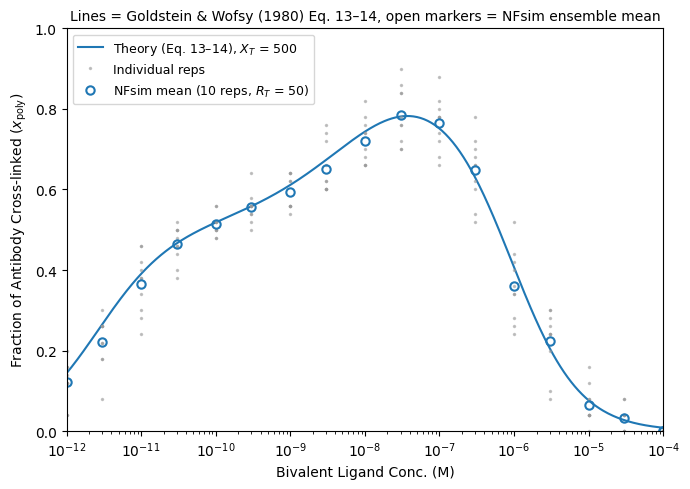

Saved verify_goldstein1980.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(A_fine, xp_theory, 'C0-', lw=1.5,
        label=f'Theory (Eq. 13–14), $X_T$ = {XT}')

# Plot all individual replicates as small grey dots
for rep in range(n_reps):
    vals = xpoly_all[:, rep]
    m = ~np.isnan(vals)
    ax.plot(A_scan[m], vals[m], '.', color='0.6', ms=3, alpha=0.5,
            label='Individual reps' if rep == 0 else None)

# Plot ensemble mean as open markers
mask = ~np.isnan(xpoly_nf)
ax.plot(A_scan[mask], xpoly_nf[mask], 'o',
        mfc='none', mec='C0', ms=6, mew=1.5,
        label=f'NFsim mean ({n_reps} reps, $R_T$ = {RT:.0f})')

ax.set_xscale('log')
ax.set_xlabel('Bivalent Ligand Conc. (M)')
ax.set_ylabel(r'Fraction of Antibody Cross-linked ($x_{\mathrm{poly}}$)')
ax.set_xlim(1e-12, 1e-4)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)
ax.set_title('Lines = Goldstein & Wofsy (1980) Eq. 13–14, '
             'open markers = NFsim ensemble mean',
             fontsize=10)
fig.tight_layout()
fig.savefig('verify_goldstein1980.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved verify_goldstein1980.png')

In [5]:
# --- Error summary ---
mask = ~np.isnan(xpoly_nf)
xp_th_scan = goldstein_xpoly(A_scan, XT, K1, K2, kappa, S_cell, r1, r2)
mask_cmp = mask & (xp_th_scan > 0.02)
if mask_cmp.sum() > 0:
    abs_err = np.abs(xpoly_nf[mask_cmp] - xp_th_scan[mask_cmp])
    print(f'Comparable points: {mask_cmp.sum()}')
    print(f'Max absolute error:  {abs_err.max():.4f}')
    print(f'Mean absolute error: {abs_err.mean():.4f}')
    if abs_err.max() < 0.20:
        print('\nPASS: NFsim agrees with Goldstein & Wofsy (1980) '
              'equilibrium theory.')
    else:
        print('\nCHECK: Some points show large deviation. '
              'Re-run or increase n_reps for better statistics.')
else:
    print('No comparable points with x_poly_theory > 0.02.')

Comparable points: 16
Max absolute error:  0.0465
Mean absolute error: 0.0173

PASS: NFsim agrees with Goldstein & Wofsy (1980) equilibrium theory.
